The metadata used for computation is shown below

/tmp/ipykernel_3291774/3179922992.py:111: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticks(), fontsize=font_size)


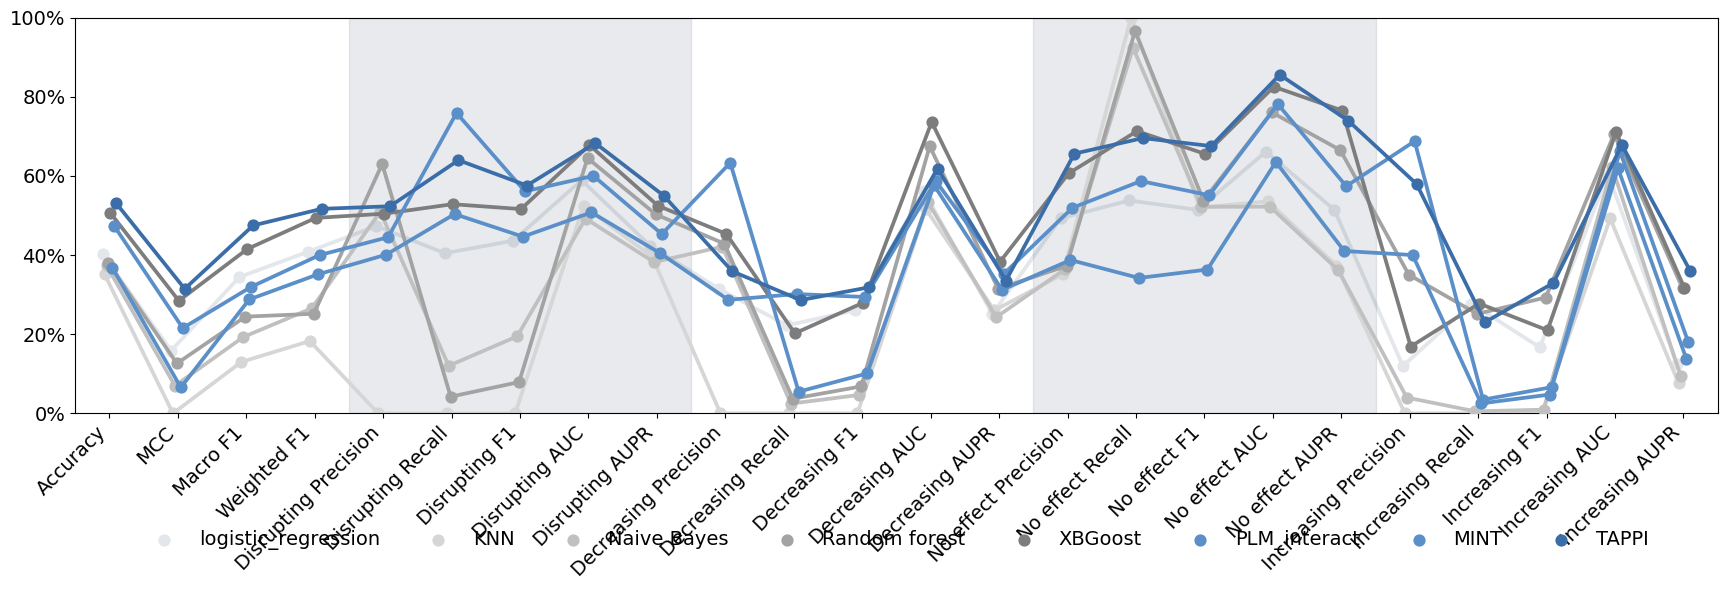

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

font_size = 14

models = ["TAPPI", "MINT", "PLM_interact", "XBGoost", "Random forest", "Naive Bayes", "KNN", "logistic_regression"][::-1]

# Categories: overall metrics first, then class-grouped
categories = [
    "Accuracy", "MCC", "Macro F1", "Weighted F1",
    "Disrupting Precision", "Disrupting Recall", "Disrupting F1", "Disrupting AUC", "Disrupting AUPR",
    "Decreasing Precision", "Decreasing Recall", "Decreasing F1", "Decreasing AUC", "Decreasing AUPR",
    "No effect Precision", "No effect Recall", "No effect F1", "No effect AUC", "No effect AUPR",
    "Increasing Precision", "Increasing Recall", "Increasing F1", "Increasing AUC", "Increasing AUPR"
]

# New data from the task
data = [
    # [0.5362637362637362, 0.33681270547260833, 0.46269233218811906, 0.5028619067539327,
    #  0.5340632603406326, 0.6157082748948106, 0.571986970684039, 0.697294, 0.5968134009408195,
    #  0.6914893617021277, 0.2138157894736842, 0.3266331658291457, 0.64944757, 0.48573320342818516,
    #  0.49816176470588236, 0.8253807106598985, 0.6213221245701186, 0.80820863, 0.5621572499656602,
    #  0.8048780487804879, 0.2082018927444795, 0.3308270676691729, 0.75194633, 0.39728950606939395
    # ],
    [0.5305, 0.3146, 0.4747, 0.5167,
    0.5232, 0.6396, 0.5756, 0.6826, 0.5499,
    0.3590, 0.2862, 0.3185, 0.6183, 0.3355,
    0.6561, 0.6954, 0.6752, 0.8554, 0.7396,
    0.5794, 0.2303, 0.3296, 0.6782, 0.3594
    ],

    
    [0.4728, 0.2155, 0.3197, 0.3999,
     0.4449, 0.7588, 0.5609, 0.6000, 0.4530,
     0.6329, 0.0548, 0.1009, 0.5877, 0.3529,
     0.5193, 0.5868, 0.5510, 0.7814, 0.5739,
     0.6875, 0.0347, 0.0661, 0.6619, 0.1794],

    [0.3676, 0.0655, 0.2878, 0.3510,
     0.4009, 0.5035, 0.4464, 0.5077, 0.4050,
     0.2868, 0.3015, 0.2940, 0.5781, 0.3118,
     0.3874, 0.3421, 0.3633, 0.6350, 0.4102,
     0.4000, 0.0252, 0.0475, 0.6189, 0.1375],

    
    [
    0.5061, 0.2844, 0.4152, 0.4938,
    0.5044, 0.5284, 0.5161, 0.6776, 0.5246,
    0.4533, 0.2022, 0.2796, 0.7360, 0.3832,
    0.6062, 0.7129, 0.6552, 0.8251, 0.7649,
    0.1688, 0.2775, 0.2099, 0.7109, 0.3165],

    [
    0.3790, 0.1261, 0.2444, 0.2516,
    0.6301, 0.0422, 0.0791, 0.6449, 0.5025,
    0.4286, 0.0370, 0.0682, 0.6750, 0.3148,
    0.3726, 0.9656, 0.5377, 0.7604, 0.6650,
    0.3504, 0.2513, 0.2927, 0.7052, 0.3162],

    [
    0.3742, 0.0698, 0.1930, 0.2654,
    0.5097, 0.1202, 0.1945, 0.4922, 0.3821,
    0.4211, 0.0247, 0.0466, 0.5348, 0.2429,
    0.3636, 0.9234, 0.5218, 0.5221, 0.3617,
    0.0400, 0.0052, 0.0093, 0.6218, 0.0953
    ],

    [
    0.3514, 0.0000, 0.1300, 0.1827,
    0.0000, 0.0000, 0.0000, 0.5244, 0.3963,
    0.0000, 0.0000, 0.0000, 0.5163, 0.2601,
    0.3514, 1.0000, 0.5200, 0.5355, 0.3732,
    0.0000, 0.0000, 0.0000, 0.4924, 0.0763
    ],

    [
    0.4035, 0.1583, 0.3445, 0.4081,
    0.4732, 0.4046, 0.4362, 0.5889, 0.4236,
    0.3151, 0.2222, 0.2606, 0.5620, 0.2508,
    0.4926, 0.5378, 0.5142, 0.6614, 0.5139,
    0.1194, 0.2775, 0.1669, 0.6034, 0.1254
    ]
    
][::-1]

df = pd.DataFrame(data, columns=categories, index=models).reset_index()
df = df.melt(id_vars="index", var_name="Category", value_name="Score")
df.rename(columns={"index": "Model"}, inplace=True)

fig, ax = plt.subplots(figsize=(18, 6))
palette = [
    "#1f3a5f",  # TAPPI – 深蓝
    "#3b6ea8",  # MINT – 蓝
    "#5b8fc9",  # PLM_interact – 浅蓝
    "#5b8fc7",

    "#7d7d7d",  # XGBoost – 深灰
    "#a3a3a3",  # Random Forest – 中灰
    "#c0c0c0",  # Naive Bayes – 浅灰
    "#d6d6d6",  # KNN – 更浅灰
    "#e3e6ea"   # Logistic Regression – 最浅灰
][::-1]

# Order by our custom categories
sns.pointplot(x="Category", y="Score", hue="Model", data=df, order=categories,
              dodge=True, palette=palette, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=font_size)
ax.set_yticklabels(ax.get_yticks(), fontsize=font_size)

n_models = len(models)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=n_models, frameon=False, fontsize=font_size)

plt.subplots_adjust(bottom=0.4)
ax.set_xlabel('', fontsize=font_size)
ax.set_ylabel('', fontsize=font_size)

def to_percent(y, _):
    return f'{y*100:.0f}%'


x_positions = range(len(categories))
ax.axvspan(x_positions[4]-0.5, x_positions[8]+0.5, color="#1f3a5f", alpha=0.1)
ax.axvspan(x_positions[14]-0.5, x_positions[18]+0.5, color="#1f3a5f", alpha=0.1)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.yaxis.set_major_formatter(FuncFormatter(to_percent))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'

# plt.tight_layout()
plt.savefig(
    "new_sep.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()
plt.close()

Download results

In [ ]:
import requests
import zipfile
import io
import os


url = "https://figshare.com/ndownloader/files/63458991"


response = requests.get(url)
response.raise_for_status() 


zip_file = zipfile.ZipFile(io.BytesIO(response.content))

zip_file.extractall(path=os.getcwd())

print("Download and extraction completed.")

TAPPI result

In [1]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'tappi_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.5305
MCC: 0.3146
Macro F1: 0.4747
Weighted F1: 0.5167

Disrupting Precision: 0.5232
Disrupting Recall: 0.6396
Disrupting F1: 0.5756
Disrupting AUC: 0.6826
Disrupting AUPR: 0.5499

Decreasing Precision: 0.3590
Decreasing Recall: 0.2862
Decreasing F1: 0.3185
Decreasing AUC: 0.6183
Decreasing AUPR: 0.3355

No effect Precision: 0.6561
No effect Recall: 0.6954
No effect F1: 0.6752
No effect AUC: 0.8554
No effect AUPR: 0.7396

Increasing Precision: 0.5794
Increasing Recall: 0.2303
Increasing F1: 0.3296
Increasing AUC: 0.6782
Increasing AUPR: 0.3594



In [17]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'mint_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.4728
MCC: 0.2155
Macro F1: 0.3197
Weighted F1: 0.3999

Disrupting Precision: 0.4449
Disrupting Recall: 0.7588
Disrupting F1: 0.5609
Disrupting AUC: 0.6000
Disrupting AUPR: 0.4530

Decreasing Precision: 0.6329
Decreasing Recall: 0.0548
Decreasing F1: 0.1009
Decreasing AUC: 0.5877
Decreasing AUPR: 0.3529

No effect Precision: 0.5193
No effect Recall: 0.5868
No effect F1: 0.5510
No effect AUC: 0.7814
No effect AUPR: 0.5739

Increasing Precision: 0.6875
Increasing Recall: 0.0347
Increasing F1: 0.0661
Increasing AUC: 0.6619
Increasing AUPR: 0.1794



In [20]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'PLM_interact_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.3676
MCC: 0.0655
Macro F1: 0.2878
Weighted F1: 0.3510

Disrupting Precision: 0.4009
Disrupting Recall: 0.5035
Disrupting F1: 0.4464
Disrupting AUC: 0.5077
Disrupting AUPR: 0.4050

Decreasing Precision: 0.2868
Decreasing Recall: 0.3015
Decreasing F1: 0.2940
Decreasing AUC: 0.5781
Decreasing AUPR: 0.3118

No effect Precision: 0.3874
No effect Recall: 0.3421
No effect F1: 0.3633
No effect AUC: 0.6350
No effect AUPR: 0.4102

Increasing Precision: 0.4000
Increasing Recall: 0.0252
Increasing F1: 0.0475
Increasing AUC: 0.6189
Increasing AUPR: 0.1375



In [21]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'xgboost_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.5061
MCC: 0.2844
Macro F1: 0.4152
Weighted F1: 0.4938

Disrupting Precision: 0.5044
Disrupting Recall: 0.5284
Disrupting F1: 0.5161
Disrupting AUC: 0.6776
Disrupting AUPR: 0.5246

Decreasing Precision: 0.4533
Decreasing Recall: 0.2022
Decreasing F1: 0.2796
Decreasing AUC: 0.7360
Decreasing AUPR: 0.3832

No effect Precision: 0.6062
No effect Recall: 0.7129
No effect F1: 0.6552
No effect AUC: 0.8251
No effect AUPR: 0.7649

Increasing Precision: 0.1688
Increasing Recall: 0.2775
Increasing F1: 0.2099
Increasing AUC: 0.7109
Increasing AUPR: 0.3165



In [22]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'randomforest_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.3790
MCC: 0.1261
Macro F1: 0.2444
Weighted F1: 0.2516

Disrupting Precision: 0.6301
Disrupting Recall: 0.0422
Disrupting F1: 0.0791
Disrupting AUC: 0.6449
Disrupting AUPR: 0.5025

Decreasing Precision: 0.4286
Decreasing Recall: 0.0370
Decreasing F1: 0.0682
Decreasing AUC: 0.6750
Decreasing AUPR: 0.3148

No effect Precision: 0.3726
No effect Recall: 0.9656
No effect F1: 0.5377
No effect AUC: 0.7604
No effect AUPR: 0.6650

Increasing Precision: 0.3504
Increasing Recall: 0.2513
Increasing F1: 0.2927
Increasing AUC: 0.7052
Increasing AUPR: 0.3162



In [23]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'knn_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.3514
MCC: 0.0000
Macro F1: 0.1300
Weighted F1: 0.1827

Disrupting Precision: 0.0000
Disrupting Recall: 0.0000
Disrupting F1: 0.0000
Disrupting AUC: 0.5244
Disrupting AUPR: 0.3963

Decreasing Precision: 0.0000
Decreasing Recall: 0.0000
Decreasing F1: 0.0000
Decreasing AUC: 0.5163
Decreasing AUPR: 0.2601

No effect Precision: 0.3514
No effect Recall: 1.0000
No effect F1: 0.5200
No effect AUC: 0.5355
No effect AUPR: 0.3732

Increasing Precision: 0.0000
Increasing Recall: 0.0000
Increasing F1: 0.0000
Increasing AUC: 0.4924
Increasing AUPR: 0.0763



In [24]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'gnb_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.3742
MCC: 0.0698
Macro F1: 0.1930
Weighted F1: 0.2654

Disrupting Precision: 0.5097
Disrupting Recall: 0.1202
Disrupting F1: 0.1945
Disrupting AUC: 0.4922
Disrupting AUPR: 0.3821

Decreasing Precision: 0.4211
Decreasing Recall: 0.0247
Decreasing F1: 0.0466
Decreasing AUC: 0.5348
Decreasing AUPR: 0.2429

No effect Precision: 0.3636
No effect Recall: 0.9234
No effect F1: 0.5218
No effect AUC: 0.5221
No effect AUPR: 0.3617

Increasing Precision: 0.0400
Increasing Recall: 0.0052
Increasing F1: 0.0093
Increasing AUC: 0.6218
Increasing AUPR: 0.0953



In [25]:
import pickle
from sklearn.metrics import (
    accuracy_score, matthews_corrcoef,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

file_path = 'logreg_results_cluster.pkl'
with open(file_path, "rb") as f:
    data = pickle.load(f)

y_test = data["y_test"]
y_pred = data["y_pred"]
y_proba = data["y_proba"]
class_names = ['Disrupting', 'Decreasing', 'No effect', 'Increasing']

accuracy = accuracy_score(y_test, y_pred)
mcc = matthews_corrcoef(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
results = {}
for i, name in enumerate(class_names):
    precision = precision_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, labels=[i], average="macro", zero_division=0)
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aupr = average_precision_score(y_test_bin[:, i], y_proba[:, i])

    results[name] = {
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc,
        "AUPR": aupr
    }

print(f"Accuracy: {accuracy:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}\n")

for name in class_names:
    print(f"{name} Precision: {results[name]['Precision']:.4f}")
    print(f"{name} Recall: {results[name]['Recall']:.4f}")
    print(f"{name} F1: {results[name]['F1']:.4f}")
    print(f"{name} AUC: {results[name]['AUC']:.4f}")
    print(f"{name} AUPR: {results[name]['AUPR']:.4f}\n")

Accuracy: 0.4035
MCC: 0.1583
Macro F1: 0.3445
Weighted F1: 0.4081

Disrupting Precision: 0.4732
Disrupting Recall: 0.4046
Disrupting F1: 0.4362
Disrupting AUC: 0.5889
Disrupting AUPR: 0.4236

Decreasing Precision: 0.3151
Decreasing Recall: 0.2222
Decreasing F1: 0.2606
Decreasing AUC: 0.5620
Decreasing AUPR: 0.2508

No effect Precision: 0.4926
No effect Recall: 0.5378
No effect F1: 0.5142
No effect AUC: 0.6614
No effect AUPR: 0.5139

Increasing Precision: 0.1194
Increasing Recall: 0.2775
Increasing F1: 0.1669
Increasing AUC: 0.6034
Increasing AUPR: 0.1254

